## Point cloud upsampling

In [3]:
!git clone https://github.com/lanshui98/UniST.git
%cd UniST

Cloning into 'UniST'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 258 (delta 73), reused 188 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (258/258), 7.39 MiB | 14.30 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/UniST


In [4]:
!pip install -r requirements.txt

#### cuda extention

In [5]:
!python setup_cuda_extensions.py

UniST CUDA Extensions Setup
Project root: /content/UniST

Defaulting to architecture 8.0 (A100, RTX 3090, etc.)
For other GPUs, set TORCH_CUDA_ARCH_LIST before running:
  export TORCH_CUDA_ARCH_LIST="7.0"  # V100
  export TORCH_CUDA_ARCH_LIST="7.5"  # RTX 2080, Titan RTX
  export TORCH_CUDA_ARCH_LIST="8.0"  # A100, RTX 3090
  export TORCH_CUDA_ARCH_LIST="8.6"  # RTX 3090, A6000

Building Chamfer3D CUDA extension...
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initi

#### The example data used for this tutorial can be downloaded from:

https://drive.google.com/file/d/1hC2pSuEsCwW_TCbAeBSUV8uY9xaczJ8Y/view?usp=sharing

and place under: `external/RepKPU_ops/dataset/`

#### The pre-trained weight can be downloaded from:

https://drive.google.com/file/d/1af_de8YnG5eOAJaSDy1C5CmZRqaCCYb-/view

and put under ./external/RepKPU_ops/pretrain/

In [ ]:
!ls external/RepKPU_ops/pretrain

ckpt-best.pth


#### Inputs should be .xyz

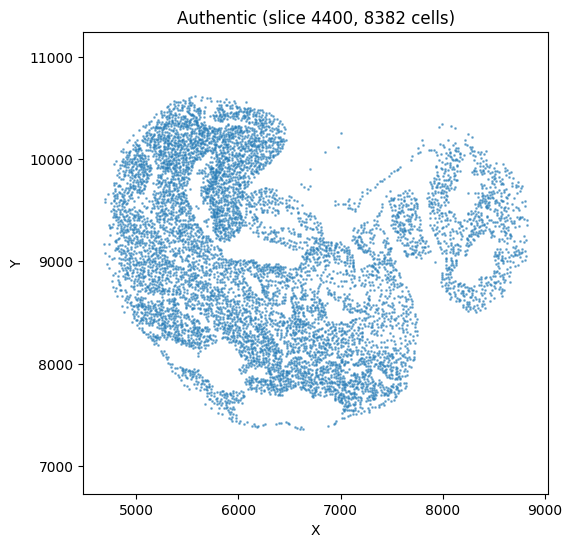

In [15]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "external/RepKPU_ops/dataset/slice440.xyz"

points = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            x, y = float(parts[0]), float(parts[1])
            points.append((x, y))

points = np.array(points)
n_points = points.shape[0]

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=1, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Authentic (slice 4400, {n_points} cells)")
plt.axis('equal')
#plt.savefig('slice440.png', format='png', dpi=300)
plt.show()

In [16]:
!python -m upsampling.test_upsampling \
    --dataset pugan \
    --input_dir /content/UniST/external/RepKPU_ops/dataset \
    --ckpt /content/UniST/external/RepKPU_ops/pretrain/ckpt-best.pth \
    --r 2 \
    --save_dir /content/UniST/external/RepKPU_ops/result \
    --flexible \
    --no_gt

Loaded compiled 3D CUDA chamfer distance

Input Directory: /content/UniST/external/RepKPU_ops/dataset
Directory exists: True
Directory is absolute: True
Directory contents (5 items):
  [FILE] slice440.xyz
  [FILE] dataset.py
  [FILE] utils.py
  [DIR] .ipynb_checkpoints
  [DIR] __pycache__

Searching for .xyz files...
  Direct search: found 1 files

=== Starting Flexible Scale Upsampling Test ===
Found 1 files

Processing file 1/1: slice440.xyz
🔍 Step 1: Reading point cloud file...
  ✓ Successfully read 8382 points
  📊 Point cloud shape: (8382, 3)

🎯 Step 2: Calculating target point count...
  📊 Input points: 8382
  📈 Upsampling rate: 2.0
  🎯 Target points: 16764

⏭️ Step 3: Skipping GT loading (no_gt flag set)

🔄 Step 4: Converting to PyTorch tensor...
  ✓ Converted to tensor: torch.Size([8382, 3])
  📱 Device: cuda:0
  ✓ After rearrangement: torch.Size([1, 3, 8382])

📏 Step 5: Normalizing point cloud...
  ✓ Normalization completed
  📊 Normalized shape: torch.Size([1, 3, 8382])
  📍 Cent

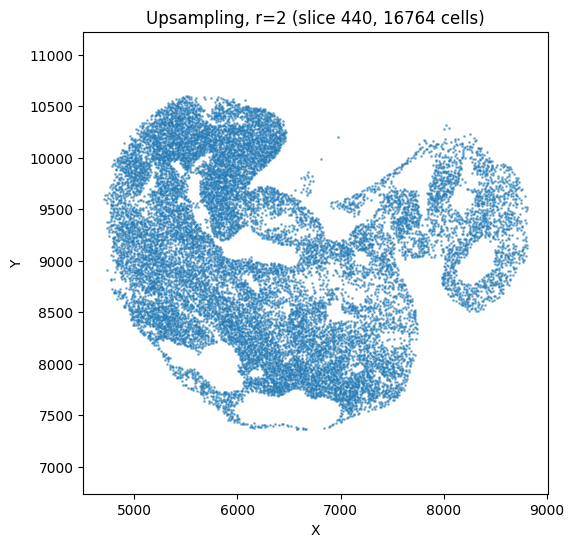

In [17]:
### visualization the results
file_path = "external/RepKPU_ops/result/xyz/slice440.xyz"

points = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            x, y = float(parts[0]), float(parts[1])
            points.append((x, y))

points = np.array(points)
n_points = points.shape[0]

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=1, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Upsampling, r=2 (slice 440, {n_points} cells)")
plt.axis('equal')
#plt.savefig('slice440_r2.png', format='png', dpi=300)
plt.show()

### Flexible upsampling rate

In [18]:
### upsampling rate = 1.3

!python -m upsampling.test_upsampling \
    --dataset pugan \
    --input_dir /content/UniST/external/RepKPU_ops/dataset \
    --ckpt /content/UniST/external/RepKPU_ops/pretrain/ckpt-best.pth \
    --r 1.3 \
    --save_dir /content/UniST/external/RepKPU_ops/result \
    --flexible \
    --no_gt

Loaded compiled 3D CUDA chamfer distance

Input Directory: /content/UniST/external/RepKPU_ops/dataset
Directory exists: True
Directory is absolute: True
Directory contents (5 items):
  [FILE] slice440.xyz
  [FILE] dataset.py
  [FILE] utils.py
  [DIR] .ipynb_checkpoints
  [DIR] __pycache__

Searching for .xyz files...
  Direct search: found 1 files

=== Starting Flexible Scale Upsampling Test ===
Found 1 files

Processing file 1/1: slice440.xyz
🔍 Step 1: Reading point cloud file...
  ✓ Successfully read 8382 points
  📊 Point cloud shape: (8382, 3)

🎯 Step 2: Calculating target point count...
  📊 Input points: 8382
  📈 Upsampling rate: 1.3
  🎯 Target points: 10896

⏭️ Step 3: Skipping GT loading (no_gt flag set)

🔄 Step 4: Converting to PyTorch tensor...
  ✓ Converted to tensor: torch.Size([8382, 3])
  📱 Device: cuda:0
  ✓ After rearrangement: torch.Size([1, 3, 8382])

📏 Step 5: Normalizing point cloud...
  ✓ Normalization completed
  📊 Normalized shape: torch.Size([1, 3, 8382])
  📍 Cent

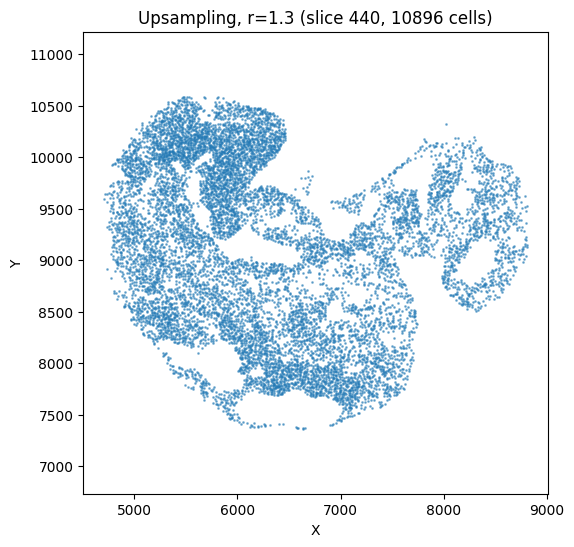

In [19]:
### visualization the results
file_path = "external/RepKPU_ops/result/xyz/slice440.xyz"

points = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            x, y = float(parts[0]), float(parts[1])
            points.append((x, y))

points = np.array(points)
n_points = points.shape[0]

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=1, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f"Upsampling, r=1.3 (slice 440, {n_points} cells)")
plt.axis('equal')
#plt.savefig('slice440_r1.3.png', format='png', dpi=300)
plt.show()